### CNNs applied to time series

In [40]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
#asdafs
%run plot.py
from useful import *
from plot import *


In [41]:
#Functions
def prepare_data_for_cnn(x, y, n_class, perc_train=0.8):

    """
    Splits, rescales, and reshapes time-series data for a 1D CNN in Keras.
    
    Parameters:
    - x: The input time-series data (array-like).
    - y: The class labels (array-like).
    - n_class: Total number of unique classes (used for printing).
    - perc_train: The fraction of data to use for training (default is 0.8).
    
    Returns:
    - x_train, y_train: Rescaled and reshaped training data and labels.
    - x_val, y_val: Rescaled and reshaped validation data and labels.
    - input_shape: The shape tuple required for the Keras Conv1D input layer.
    """
    
    # Convert to numpy arrays of floats to allow proper division and prevent modifying originals
    x = np.array(x, dtype=float)
    y = np.array(y)
    
    N = len(x)
    L = x.shape[1] if len(x.shape) > 1 else len(x[0])
    
    # split into training and validation sets
    N_train = int(perc_train * N)
    x_train = x[:N_train]
    y_train = y[:N_train]
    
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
    #print('x_train shape:', x_train.shape)
    #print(f'N_train={N_train}  N_val={N_val}  L={L}  n_class={n_class}')

    # ---> (two steps) rescaling:
    # remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    
    print('std_train (max, min, mean):', max(std_train), min(std_train), std_train.mean(axis=0))
    print('std_val (max, min, mean):', max(std_val), min(std_val), std_val.mean(axis=0))

    # rescale with variance on the training set
    std_mean_train = std_train.mean(axis=0)
    for i in range(N_train):
         # ---> NB to account for drift + varying jump length; to avoid "smoothing out" the pattern
         x_train[i] = (x_train[i] - xm_train[i]) / std_mean_train

    std_mean_val = std_val.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i] - xm_val[i]) / std_mean_val
        
    # Visualize the rescaled data 
    # (assumes Show_data is defined globally in your notebook)
    #Show_data(x_train, L, "rescaled train data")
    #Show_data(x_val, L, "rescaled validation data")

    # Keras wants an additional dimension with a 1 at the end
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val = x_val.reshape(x_val.shape[0], L, 1)
    input_shape = (L, 1) # number of features, number of channels (1 for 1D data)
    
    return x_train, y_train, x_val, y_val, input_shape

def build_cnn_model(input_shape, n_class=3, NCONV=1, NF=5):
    """
    Builds and compiles a 1D CNN model for time-series classification.
    
    Parameters:
    - input_shape: Tuple representing (time_steps, channels), e.g., (60, 1).
    - n_class: Number of output classes for the softmax layer.
    - NCONV: Switch between architectures (1 = Two Conv layers, 2 = One Conv layer).
    - NF: Number of filters for the first Conv1D layer.
    
    Returns:
    - Compiled Keras Sequential model.
    """
    # Reproducibility seeds
    np.random.seed(12345)
    tf.random.set_seed(12345)

    # Regularization and Initialization
    reg = tf.keras.regularizers.l2(0.2)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=None)

    model = Sequential()
    
    if NCONV == 1:
        # ----- Architecture with 2 Convolutional Layers -----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg,
                         activation='relu', 
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
        
    elif NCONV == 2:
        # ----- Architecture with 1 Convolutional Layer -----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg,
                         activation='relu', 
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))

    # Output layer
    model.add(Dense(n_class, activation='softmax'))

    # Compile the model
    opt = tf.keras.optimizers.Adam()
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=opt, 
                  metrics=['accuracy'])
    #print('----- Model',NCONV,'-----')
    #print(model.summary())
    
    return model

def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()

def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()

### Read data

In [42]:
all_histories = [] 
Arange = np.arange(50, 1050, 50)

for a in Arange:
    str0 = f'ts_L60_Z12_A{a}_DX50_bias5_N10000.dat'
    fnamex = 'DATA/x_' + str0
    fnamey = 'DATA/y_' + str0

    x = np.loadtxt(fnamex, delimiter=" ", dtype=float)
    N, L = len(x), len(x[0])

    categ = np.loadtxt(fnamey, dtype=int)
    n_class = 3    
    print(f'Training A={a}... (Data: {N} samples)')

    y = np.zeros((N, n_class))
    for i in range(N):
        y[i][categ[i]] = 1. 
        
    x_train, y_train, x_val, y_val, input_shape = prepare_data_for_cnn(x, y, n_class=3)
    
    BATCH_SIZE = 200
    EPOCHS = 150

    # ----- Train Model 1 (L2 Regularization) -----
    model_1 = build_cnn_model(input_shape=input_shape, n_class=3, NCONV=1)
    
    fit1 = model_1.fit(x_train, y_train, batch_size=BATCH_SIZE,
                       epochs=EPOCHS,
                       validation_data=(x_val, y_val),
                       verbose=0, shuffle=True) 
                       
    # ----- Train Model 2 (L1 Regularization) -----
    reg2 = tf.keras.regularizers.l1(0.5)
    model_2 = keras.models.clone_model(model_1)
    
    # Overwrite the regularizers in the cloned layers
    model_2.layers[0].kernel_regularizer = reg2
    model_2.layers[2].kernel_regularizer = reg2
    
    opt2 = tf.keras.optimizers.Adam()
    model_2.compile(loss=keras.losses.categorical_crossentropy, 
                    optimizer=opt2, 
                    metrics=['accuracy'])
    
    fit2 = model_2.fit(x_train, y_train, batch_size=BATCH_SIZE,
                       epochs=EPOCHS,
                       validation_data=(x_val, y_val), 
                       verbose=0, shuffle=True)
                       
    # Store both histories for the multiplot
    all_histories.append((fit1.history, fit2.history))

Training A=50... (Data: 10000 samples)
std_train (max, min, mean): 579.2066662446334 42.75607819038391 163.92633476977798
std_val (max, min, mean): 542.5048233272524 50.39557685617524 165.31540913961476


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training A=100... (Data: 10000 samples)
std_train (max, min, mean): 549.6136650715058 49.391460687945745 164.66749932221416
std_val (max, min, mean): 529.3850950762488 44.357061319353534 167.76596781032305
Training A=150... (Data: 10000 samples)
std_train (max, min, mean): 533.6807399768351 39.3015973664628 167.54986192309087
std_val (max, min, mean): 515.465840014857 43.88868178572796 168.7136825291259
Training A=200... (Data: 10000 samples)
std_train (max, min, mean): 572.4524519313567 43.48796449082844 168.506912884188
std_val (max, min, mean): 557.6467031692697 48.5362293092032 169.22766095456487
Training A=250... (Data: 10000 samples)
std_train (max, min, mean): 520.0385391701486 47.16017623188257 174.6062321569844
std_val (max, min, mean): 490.54348402789145 45.616468760988305 174.1007875219706
Training A=300... (Data: 10000 samples)
std_train (max, min, mean): 610.6378220534839 48.46440847559051 178.4402794259962
std_val (max, min, mean): 493.3409264618356 57.446922362202216 180

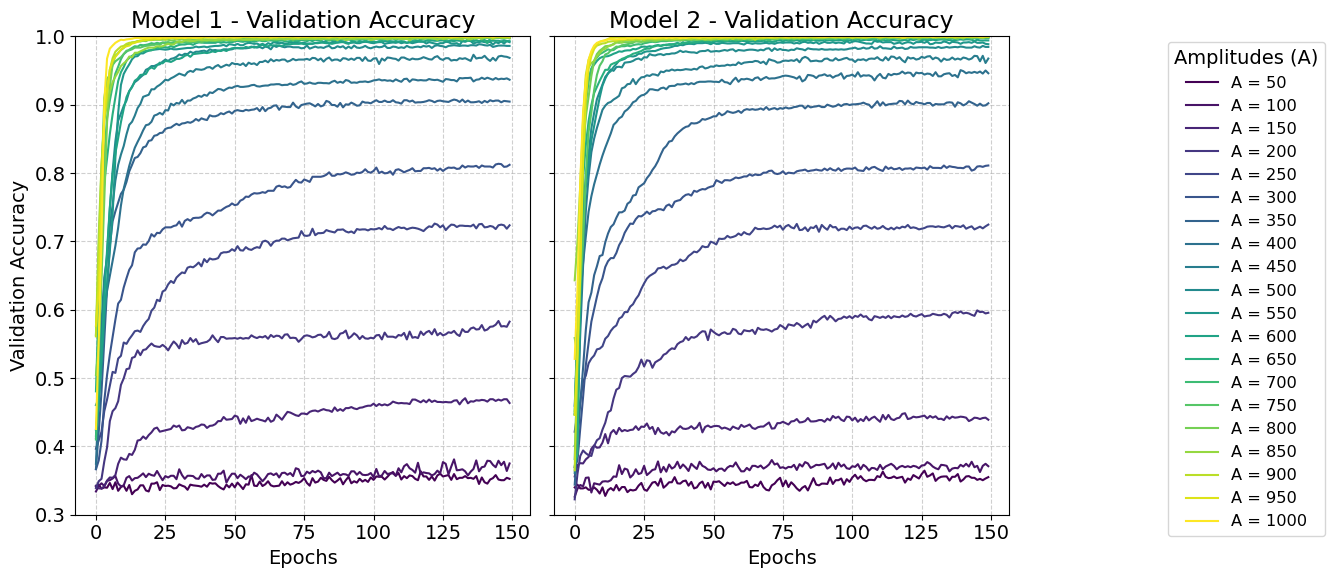

In [43]:
num_A = len(all_histories)

# Create a figure with 1 row and 2 columns (one for each model)
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Generate a sequential colormap (viridis) for the 20 different A values
colors = cm.viridis(np.linspace(0, 1, num_A))

for idx, (hist1, hist2) in enumerate(all_histories):
    current_A = 50 + idx * 50
    
    # Plot Model 1 Validation Accuracy on the left subplot
    axes[0].plot(hist1['val_accuracy'], color=colors[idx], label=f'A = {current_A}', linewidth=1.5)
    
    # Plot Model 2 Validation Accuracy on the right subplot
    axes[1].plot(hist2['val_accuracy'], color=colors[idx], label=f'A = {current_A}', linewidth=1.5)

# --- Format Model 1 Plot ---
axes[0].set_title('Model 1 - Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_ylim(0.3, 1.0) # <--- Y-axis updated here
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Format Model 2 Plot ---
axes[1].set_title('Model 2 - Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Global Legend and Layout ---
# Extract handles and labels once, place legend outside the plots to prevent blocking data
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5), title="Amplitudes (A)", fontsize='small')

plt.tight_layout()
plt.subplots_adjust(right=0.85) # Leave room on the right for the external legend
plt.show()